Use spy regime as a general context for position sizing

Focus on medium term trend and medium term vol with short term volatility. Assumption

1. market regime typically shift gradually.
1. trend and vol should continue in the future
1. medium term extrem vol will create potential of big reverse due to extreme positioning
1. mdium term trend with mild vol is a good opportunity to add bet reverting to long term trend

In [1]:
from sts.dio.equity import TickerDatabase as Ticker
import pandas as pd
import os
import plotly.io as pio
from sts.quant.candle import Candle
from sts.quant.volatility import atr
from sts.plots.time_series_plots import plot_multi_time_series
from sts.stsig.ta.market_regime import SQNRegime
pd.options.plotting.backend = 'plotly'
from sts.quant.breakout import get_breakout_mm_multi_horizon
from IPython.display import clear_output

In [2]:
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'png')
short_horizon, long_horizon = 20, 80    # ratio 1:4, this does not matter
period = '2y'
spy_ticker = Ticker('SPY')
spy_df = Candle(spy_ticker.history(period = period))
vix_ticker = Ticker('^VIX')
vix_df = vix_ticker.history(period = period)
short_sqn = SQNRegime(sqn_window = short_horizon)
short_sqn.set_data(spy_df.copy())
long_sqn = SQNRegime(sqn_window = long_horizon)
long_sqn.set_data(spy_df.copy())
vix_df['CloseLong'] = vix_df['Close'].clip(upper = 35).rolling(window = long_horizon).mean()
vix_df['CloseShort'] = vix_df['Close'].clip(upper = 35).rolling(window = short_horizon).mean()
fig = Candle(spy_df.resample('1W')).make_subplots(rows = 3, cols = 1)
sqn_fig = pd.DataFrame({'SQNShort':short_sqn.df['SQNLog'], 'SQNLong':long_sqn.df['SQNLog']}).plot()
vix_fig = vix_df[['CloseLong', 'CloseShort']].rename(columns = {'CloseLong':'VixLong', 'CloseShort':'VixShort'}).plot()
for data in sqn_fig.data:
    fig.add_trace(data, row = 2, col = 1)

for data in vix_fig.data:
    fig.add_trace(data, row = 3, col = 1)
clear_output()

KeyError: 'timestamp'

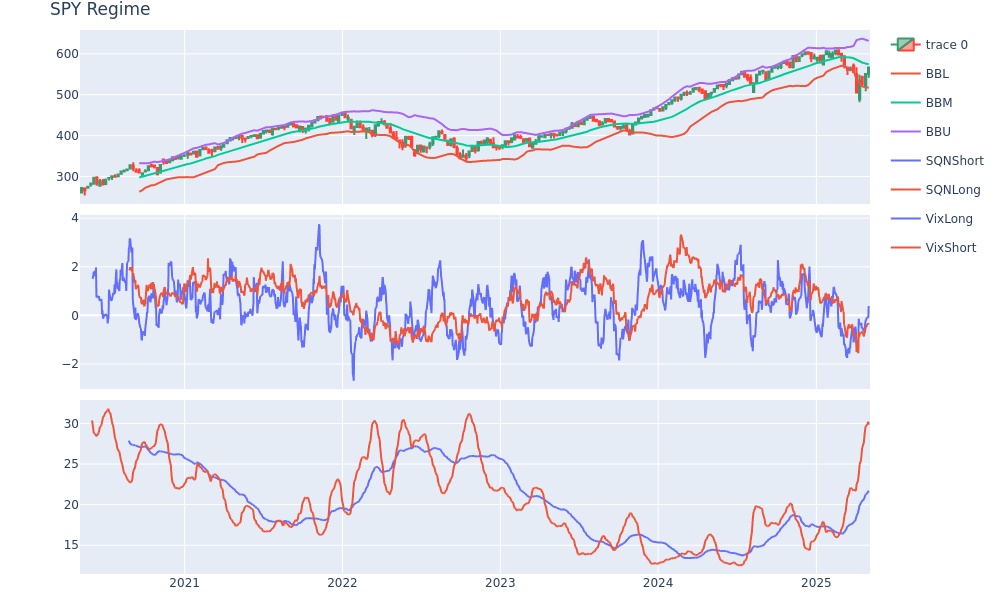

In [65]:
fig.update_layout(margin = dict(t = 30, b = 10), width = 1000, height = 600, title = 'SPY Regime')
fig.show()

In [ ]:
from polygon import 